In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score,confusion_matrix, f1_score, recall_score, precision_score, precision_recall_curve

import optuna
import logging
import shap

df = pd.read_excel(r"C://Users//vinic//OneDrive//Área de Trabalho//base_datathon_pm_vf.xlsx")


In [17]:
df['PEDRA'] = df['PEDRA'].astype(str).str.strip()
df['PEDRA'] = df['PEDRA'].replace({
    'Agata': 'Ágata',
    'Ágata': 'Ágata', 
    'Quartzo ': 'Quartzo',
    'Topazio': 'Topázio',
    'Ametista ': 'Ametista'
})
pedras_validas = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df = df[df['PEDRA'].isin(pedras_validas)]
ordem = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df['PEDRA'] = pd.Categorical(df['PEDRA'], categories=ordem, ordered=True)

In [18]:
cols_kpi = ['IAN', 'IEG', 'IDA', 'IPS', 'IPP', 'IPV', 'INDE']

for col in cols_kpi:
    df[col] = (df[col].astype(str).str.replace(',', '.'))
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [19]:
df = df.sort_values(['ID_ALUNO', 'ANO'])
df.head(2)

,NOME,ID_ALUNO,ANO,ANO_INGRESSO,BOLSISTA,CF,CG,CT,DEFASAGEM,FASE,...,INDE,INDICADO_BOLSA,IPP,IPS,IPV,NOTA_ING,NOTA_MAT,NOTA_PORT,PEDRA,PONTO_VIRADA
0,ALUNO-1,1,2020,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,7.883752,0,5.9375,7.5,7.75,NaN,NaN,NaN,Ametista,0
1,ALUNO-1,1,2021,NaN,0.0,NaN,NaN,NaN,-1.0,2.0,...,7.319000,0,7.7000,6.9,8.10,NaN,NaN,NaN,Ametista,0


In [20]:
df['IAN_LAG'] = df.groupby('ID_ALUNO')['IAN'].shift(1)
df['DELTA_IAN'] = df['IAN'] - df['IAN_LAG']

In [ ]:
df_model = df.dropna(subset=['IAN_LAG']).copy()
df_model['TARGET'] = (df_model['DELTA_IAN'] < 0).astype(int)

features = ['IAN_LAG', 'IEG', 'IDA', 'IPS', 'IPP', 'IPV']

for col in features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

--------------------------
 Modelo 1. Random Forest 


In [35]:
X = df_model[features]
y = df_model['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=42, stratify=y)
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

--------------------------
 Modelo 1. Random Forest 


              precision    recall  f1-score   support

           0       0.92      0.84      0.88       713
           1       0.50      0.67      0.58       169

    accuracy                           0.81       882
   macro avg       0.71      0.76      0.73       882
weighted avg       0.84      0.81      0.82       882

ROC AUC: 0.8563449712440974


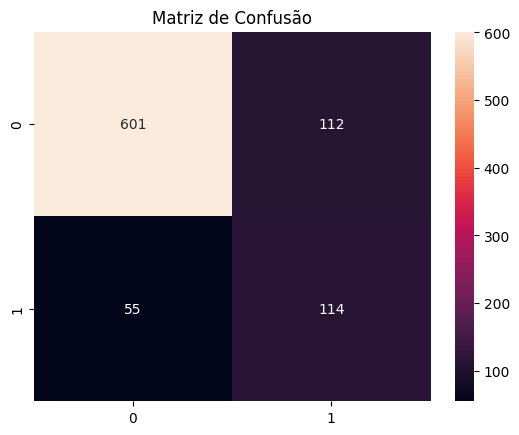

In [36]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
y_pred_new = (y_prob > 0.35).astype(int)

print(classification_report(y_test, y_pred_new))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
sns.heatmap(confusion_matrix(y_test, y_pred_new), annot=True, fmt='d')
plt.title('Matriz de Confusão')
plt.show()

--------------------------
 Modelo 2. XGBOOST


              precision    recall  f1-score   support

           0       0.90      0.87      0.89       713
           1       0.53      0.60      0.57       169

    accuracy                           0.82       882
   macro avg       0.72      0.74      0.73       882
weighted avg       0.83      0.82      0.83       882

ROC AUC: 0.8503946156335842


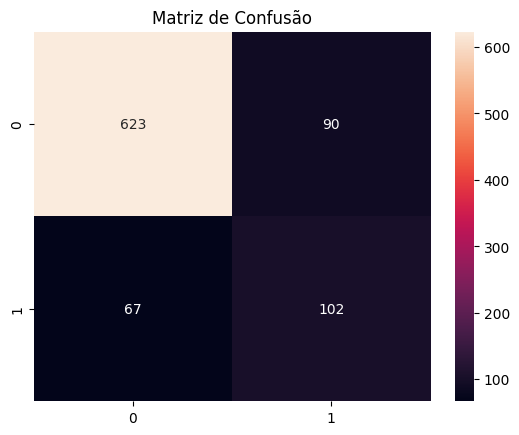

In [37]:
xgb = XGBClassifier(random_state=42,eval_metric='logloss')
xgb.fit(X_train, y_train)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb = (y_prob_xgb > 0.35).astype(int)
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title('Matriz de Confusão')
plt.show()

--------------------------
Clusterização - Kmeans


In [38]:
cluster_features = ['IEG','IDA','IPV','IPS','IPP']
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_model[cluster_features])

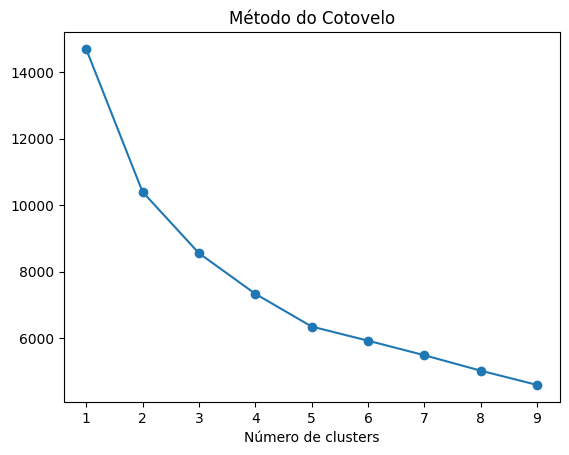

In [39]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)
plt.plot(K_range, inertia, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de clusters')
plt.show()

In [40]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_model['CLUSTER'] = kmeans.fit_predict(X_cluster)

--------------------------
Modelo 3. - XGBOOST + Kmeans


In [41]:
features_kmeans = features + ['CLUSTER']
X = df_model[features_kmeans]
y = df_model['TARGET']


X_train_kmeans, X_test_kmeans, y_train_kmeans, y_test_kmeans = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       713
           1       0.50      0.56      0.53       169

    accuracy                           0.81       882
   macro avg       0.70      0.71      0.70       882
weighted avg       0.82      0.81      0.81       882

ROC AUC: 0.8479962156734192


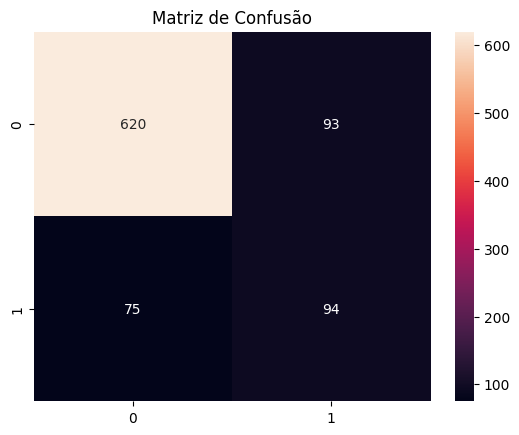

In [42]:
xgb.fit(X_train_kmeans, y_train_kmeans)

y_prob = xgb.predict_proba(X_test_kmeans)[:,1]
y_pred = (y_prob > 0.35).astype(int)

print(classification_report(y_test_kmeans, y_pred))
print("ROC AUC:", roc_auc_score(y_test_kmeans, y_prob))
sns.heatmap(confusion_matrix(y_test_kmeans, y_pred), annot=True, fmt='d')
plt.title('Matriz de Confusão')
plt.show()

------------------------------------------------------
Modelo 4. Random Forest + Optuna

In [43]:
def objective_rf(trial):   
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight": "balanced",
        "random_state": 42,
        "verbose": 0
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.35).astype(int)
    
    return f1_score(y_test, y_pred)

In [44]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_rf = optuna.create_study(direction="maximize")

study_rf.optimize(objective_rf,n_trials=50,show_progress_bar=True)
best_rf_params = study_rf.best_params

Best trial: 13. Best value: 0.620123: 100%|██████████| 50/50 [00:22<00:00,  2.18it/s]


------------------------------------------------------
Modelo 4. Random Forest + Optuna

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       713
           1       0.50      0.45      0.47       169

    accuracy                           0.81       882
   macro avg       0.69      0.67      0.68       882
weighted avg       0.80      0.81      0.81       882

ROC AUC: 0.8534320356523399
Recall (classe 1): 0.44970414201183434
Precision: 0.5033112582781457
F1: 0.475


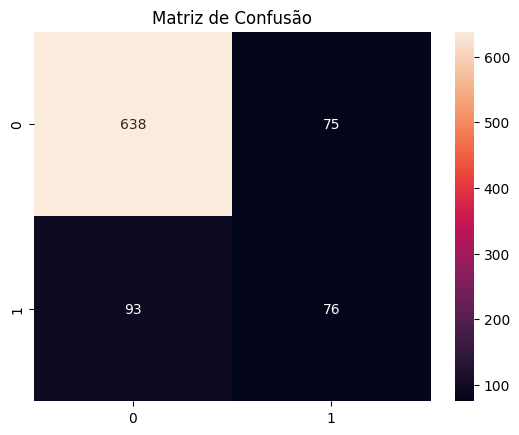

In [45]:
rf_best = RandomForestClassifier(**best_rf_params,random_state=42,n_jobs=-1)
rf_best.fit(X_train, y_train)
y_pred_rf = rf_best.predict(X_test)
y_proba_rf = rf_best.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_rf))

print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print("Recall (classe 1):", recall_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title('Matriz de Confusão')
plt.show()

------------------------------------------------
Modelo 5. XGBOOST + OPTUNA


In [46]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "random_state": 42,
        "eval_metric": "logloss"
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:,1]

    return f1_score(y_test, y_pred)

In [47]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb,n_trials=50,show_progress_bar=True)
best_xgb_params = study_xgb.best_params

Best trial: 0. Best value: 0.52809: 100%|██████████| 50/50 [00:08<00:00,  5.56it/s]


              precision    recall  f1-score   support

           0       0.87      0.89      0.88       713
           1       0.50      0.46      0.48       169

    accuracy                           0.81       882
   macro avg       0.69      0.67      0.68       882
weighted avg       0.80      0.81      0.80       882

ROC AUC: 0.854855307601019
Recall (classe 1): 0.4556213017751479
Precision: 0.5
F1: 0.47678018575851394


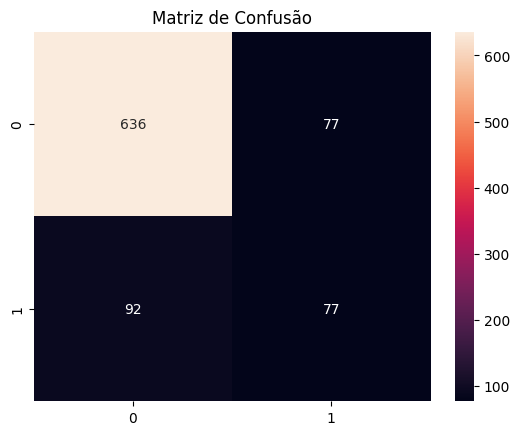

In [48]:
xgb_best = XGBClassifier(**best_xgb_params,random_state=42,eval_metric='logloss')
xgb_best.fit(X_train, y_train)
y_pred_xgb = xgb_best.predict(X_test)
y_proba_xgb = xgb_best.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_xgb))

print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))
print("Recall (classe 1):", recall_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title('Matriz de Confusão')
plt.show()

In [49]:
comparison = pd.DataFrame({
    "Modelo": ["Random Forest", "XGBoost"],
    "ROC AUC": [
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    "Recall_Classe_1": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

comparison

,Modelo,ROC AUC,Recall_Classe_1,F1
0,Random Forest,0.853432,0.449704,0.47500
1,XGBoost,0.854855,0.455621,0.47678


-------------------------

In [50]:
scale_pos_weight = (len(y_train[y_train == 0]) / len(y_train[y_train == 1]))

xgb_best = XGBClassifier(**best_xgb_params,random_state=42,eval_metric='logloss', scale_pos_weight=scale_pos_weight)
xgb_best.fit(X_train, y_train)

y_pred_default = xgb_best.predict(X_test)
y_proba = xgb_best.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_default))

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Recall:", recall_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default))
print("F1:", f1_score(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.96      0.79      0.86       713
           1       0.49      0.85      0.62       169

    accuracy                           0.80       882
   macro avg       0.72      0.82      0.74       882
weighted avg       0.87      0.80      0.82       882

ROC AUC: 0.8551001269741155
Recall: 0.8461538461538461
Precision: 0.4880546075085324
F1: 0.6190476190476191


In [51]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    results.append({
        "threshold": t,
        "recall": recall_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t)
    })

results_df = pd.DataFrame(results)
results_df

,threshold,recall,precision,f1
0,0.2,0.934911,0.464706,0.620825
1,0.3,0.911243,0.466667,0.617234
2,0.4,0.869822,0.472669,0.612500
3,0.5,0.846154,0.488055,0.619048
4,0.6,0.769231,0.494297,0.601852


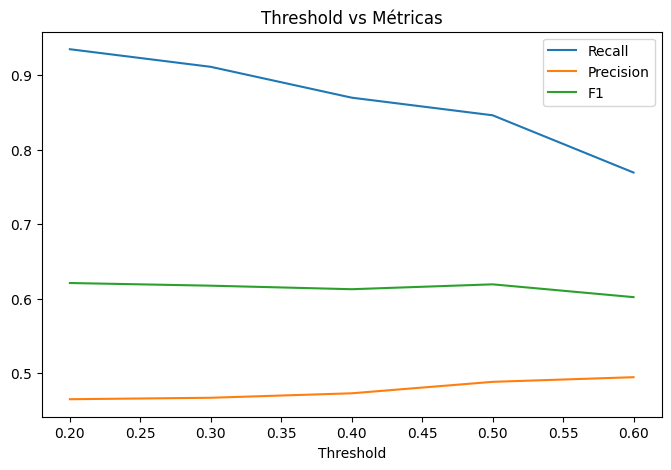

In [52]:
plt.figure(figsize=(8,5))

plt.plot(results_df['threshold'], results_df['recall'], label='Recall')
plt.plot(results_df['threshold'], results_df['precision'], label='Precision')
plt.plot(results_df['threshold'], results_df['f1'], label='F1')

plt.legend()
plt.title('Threshold vs Métricas')
plt.xlabel('Threshold')

plt.show()

----------------------------
Escolha Modelo - XGBOOST + OPTUNA + Threshold = 0.3 

In [82]:
features_modelo = ['IAN_LAG', 'IEG', 'IDA', 'IPS', 'IPP', 'IPV']

scaler_model = StandardScaler()

X_train_scaled = scaler_model.fit_transform(X_train[features_modelo])
X_test_scaled = scaler_model.transform(X_test[features_modelo])

In [83]:
scale_pos_weight = (len(y_train[y_train == 0]) / len(y_train[y_train == 1]))

xgb_best = XGBClassifier(**best_xgb_params,random_state=42,eval_metric='logloss', scale_pos_weight=scale_pos_weight)
xgb_best.fit(X_train_scaled, y_train)

y_pred_default = xgb_best.predict(X_test_scaled)
y_proba = xgb_best.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_default))

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Recall:", recall_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default))
print("F1:", f1_score(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.96      0.79      0.86       713
           1       0.49      0.85      0.62       169

    accuracy                           0.80       882
   macro avg       0.72      0.82      0.74       882
weighted avg       0.87      0.80      0.82       882

ROC AUC: 0.8551001269741155
Recall: 0.8461538461538461
Precision: 0.4880546075085324
F1: 0.6190476190476191


              precision    recall  f1-score   support

           0       0.97      0.75      0.85       713
           1       0.47      0.91      0.62       169

    accuracy                           0.78       882
   macro avg       0.72      0.83      0.73       882
weighted avg       0.88      0.78      0.80       882

Recall: 0.9112426035502958
Precision: 0.4666666666666667
F1: 0.6172344689378757


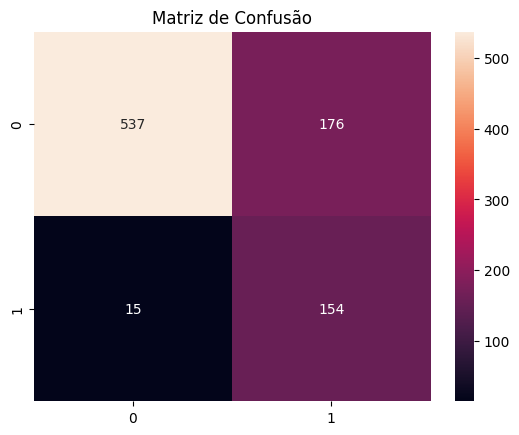

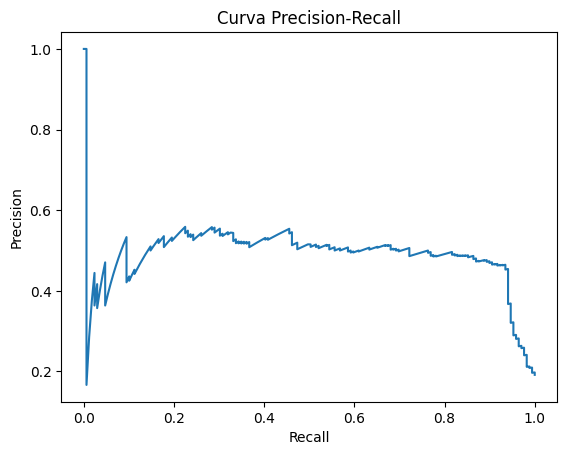

In [84]:
threshold_final = 0.3

y_pred_final = (y_proba >= threshold_final).astype(int)
print(classification_report(y_test, y_pred_final))

print("Recall:", recall_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("F1:", f1_score(y_test, y_pred_final))

sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d')
plt.title('Matriz de Confusão')
plt.show()

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")

plt.show()

In [85]:
df_result = X_test.copy()
df_result['TARGET_REAL'] = y_test.values
df_result['PROB_RISCO'] = y_proba
df_result['PRED_FINAL'] = y_pred_final

df_result.head(10).reset_index(drop=True)

,IAN_LAG,IEG,IDA,IPS,IPP,IPV,TARGET_REAL,PROB_RISCO,PRED_FINAL
0,5.0,8.801282,5.800000,5.00,7.031250,6.749998,0,0.042243,0
1,5.0,10.000000,9.600000,8.13,7.343750,8.920000,0,0.009056,0
2,5.0,10.000000,7.500000,8.13,7.343750,9.450000,0,0.020385,0
3,5.0,8.200000,7.100000,7.52,7.343750,7.613333,0,0.033641,0
4,10.0,9.700000,9.600000,7.50,7.343750,8.278000,1,0.715430,1
5,10.0,8.200000,7.500000,5.00,7.343750,8.045000,0,0.758975,1
6,10.0,3.800000,3.100000,7.50,7.300000,7.600000,0,0.672638,1
7,10.0,8.300000,7.800000,7.50,7.800000,7.300000,0,0.820380,1
8,10.0,8.369048,8.055556,7.50,6.041667,8.500005,0,0.915256,1
9,10.0,9.400000,7.500000,7.50,7.343750,7.500000,1,0.670749,1


--------------------------
Analise SHAP + Plano de Ação


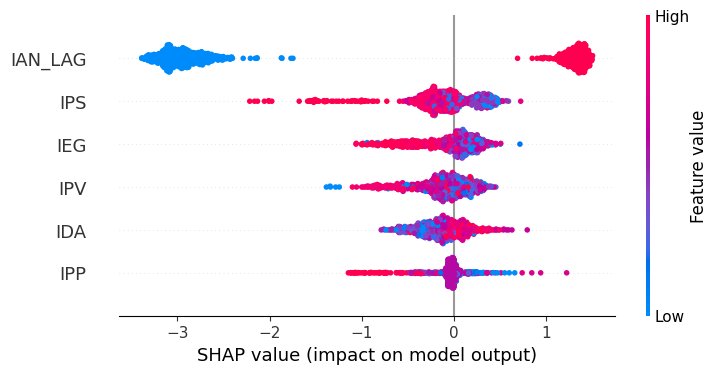

In [56]:
explainer = shap.Explainer(xgb_best)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

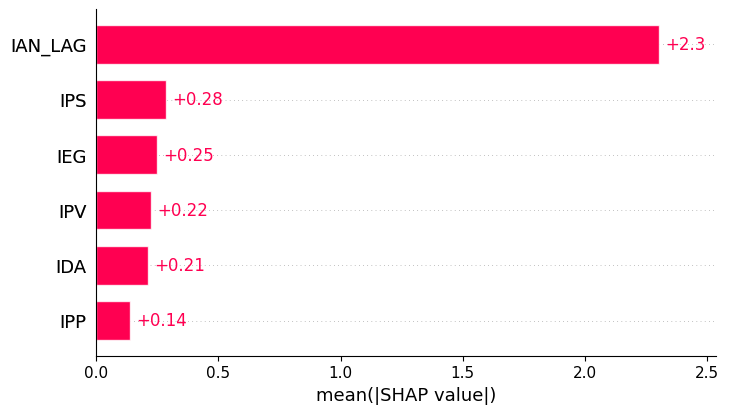

In [57]:
shap.plots.bar(shap_values)

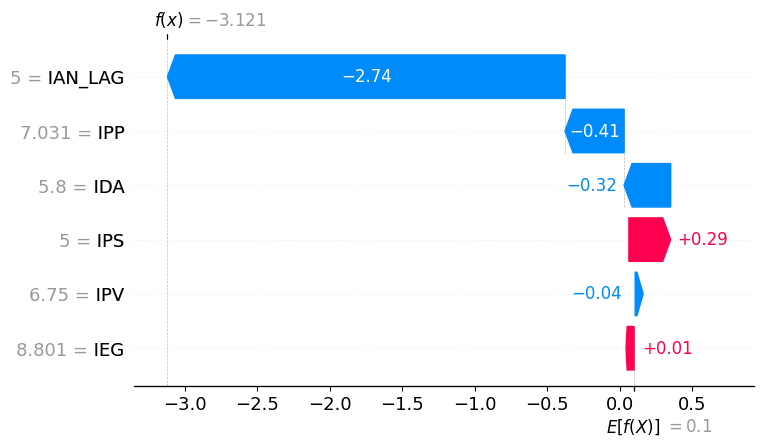

In [58]:
idx = 0

shap.plots.waterfall(shap_values[idx])

------------
SHAP + Clusters

In [59]:
print(df_model.index.equals(X_test.index)) 

False


In [60]:
df_result['CLUSTER'] = df_model.loc[X_test.index, 'CLUSTER']
shap_df = pd.DataFrame(shap_values.values,columns=X_test.columns,index=X_test.index)
shap_df['CLUSTER'] = df_result['CLUSTER']
shap_cluster = shap_df.groupby('CLUSTER').mean()

shap_cluster

,IAN_LAG,IEG,IDA,IPS,IPP,IPV
CLUSTER,,,,,,
0,-1.050955,-0.147303,-0.030462,-0.239320,-0.127215,-0.172425
1,-1.649281,0.037175,-0.173225,-0.046646,0.149218,-0.115229
2,-1.387169,-0.128941,-0.136685,0.208805,-0.036016,-0.158452
3,-1.416738,0.086157,-0.263604,-0.158651,-0.069433,0.003508


In [61]:
idx = 0
shap_df.head(10).reset_index(drop=True)

,IAN_LAG,IEG,IDA,IPS,IPP,IPV,CLUSTER
0,-2.744018,0.007708,-0.321478,0.288388,-0.407863,-0.043416,2
1,-2.863750,-0.283329,0.115400,-0.974711,-0.106117,-0.682227,0
2,-2.773577,-0.235192,0.032854,-1.009436,-0.085673,0.099171,0
3,-3.284189,0.135321,0.076746,-0.232767,-0.018045,-0.134361,0
4,1.336518,-0.742151,0.307876,0.094304,-0.000315,-0.173840,0
5,1.367464,0.238237,-0.082084,0.182804,-0.005928,-0.652935,2
6,1.416646,0.134802,-0.537510,-0.075549,-0.258829,-0.058932,3
7,1.352498,0.193957,-0.003016,-0.020028,-0.272843,0.168844,0
8,1.473474,0.277776,0.111913,0.007926,0.317016,0.091954,1
9,1.346120,-0.361885,-0.019893,-0.219838,-0.011222,-0.121220,0


--------------
Algoritmo de Decisão - Plano de Ação 


In [62]:
shap_df = pd.DataFrame(shap_values.values,columns=X_test.columns,index=X_test.index)

shap_df['KPI_CRITICO'] = shap_df.apply(lambda row: row[row > 0].abs().idxmax() if any(row > 0) else row.abs().idxmax(),axis=1)
perfil_cluster = {
    0: "Deterioração gradual",
    1: "Risco estrutural",
    2: "Falha de aprendizado",
    3: "Queda recente de aprendizado"
}
def diagnostico(row):
    kpi = row['KPI_CRITICO']
    if kpi == 'IDA':
        return "Baixo desempenho acadêmico"
    elif kpi == 'IEG':
        return "Baixo engajamento"
    elif kpi == 'IPS':
        return "Baixa participação"
    elif kpi == 'IPP':
        return "Baixa persistência"
    elif kpi == 'IAN_LAG':
        return "Histórico de baixo desempenho"
    elif kpi == 'IPV':
        return "Baixa velocidade de aprendizado"
    else:
        return "Indefinido"
    

def acao(row):
    kpi = row['KPI_CRITICO']
    cluster = row['CLUSTER']
    
    if kpi == 'IDA':
        return "Ação deve ser tomada com direcionamento do conteúdo e adaptação de exercícios"
    
    elif kpi == 'IEG':
        return "Aumentar engajamento com acompanhamento ativo e metas de participação nas atividades"
    
    elif kpi == 'IPS':
        return "Promover participação com controle de presença e atividades semanais"
    
    elif kpi == 'IPP':
        return "Trabalhar persistência com acompanhamento individual e metas de continuidade"
    
    elif kpi == 'IAN_LAG':
        return "Implementar plano de recuperação progressivo baseado no histórico"
    
    elif kpi == 'IPV':
        return "Ajustar ritmo de ensino com reforço incremental e revisão contínua"
    
    return "Ação não definida"
    

In [63]:
algoritmo = df_result.copy()
algoritmo[['IAN_LAG','IEG','IDA','IPS','IPP','IPV']] = X_test
algoritmo['CLUSTER'] = df_model.loc[X_test.index, 'CLUSTER']
algoritmo['PERFIL'] = algoritmo['CLUSTER'].map(perfil_cluster)

algoritmo['KPI_CRITICO'] = shap_df['KPI_CRITICO']

algoritmo['DIAGNOSTICO'] = algoritmo.apply(diagnostico, axis=1)

algoritmo['ACAO'] = algoritmo.apply(acao, axis=1)

algoritmo['PEDRA'] = df.loc[X_test.index, 'PEDRA']
algoritmo['ANO'] = df.loc[X_test.index, 'ANO']

In [64]:
algoritmo['ID_ALUNO'] = df.loc[X_test.index, 'ID_ALUNO']
algoritmo['NOME'] = df.loc[X_test.index, 'NOME']
# shap_df = pd.DataFrame(shap_values.values,columns=X_test.columns,index=X_test.index)

algortimo_decisao = algoritmo[['ID_ALUNO','NOME','ANO','CLUSTER','IAN_LAG','IEG','IDA','IPS','IPP','IPV','PEDRA','PERFIL','KPI_CRITICO','DIAGNOSTICO','ACAO']]

algortimo_decisao.head().reset_index(drop=True)

,ID_ALUNO,NOME,ANO,CLUSTER,IAN_LAG,IEG,IDA,IPS,IPP,IPV,PEDRA,PERFIL,KPI_CRITICO,DIAGNOSTICO,ACAO
0,958,ALUNO-958,2022,2,5.0,8.801282,5.8,5.00,7.03125,6.749998,Ágata,Falha de aprendizado,IPS,Baixa participação,Promover participação com controle de presença...
1,861,Aluno-861,2023,0,5.0,10.000000,9.6,8.13,7.34375,8.920000,Topázio,Deterioração gradual,IDA,Baixo desempenho acadêmico,Ação deve ser tomada com direcionamento do con...
2,688,Aluno-688,2024,0,5.0,10.000000,7.5,8.13,7.34375,9.450000,Topázio,Deterioração gradual,IPV,Baixa velocidade de aprendizado,Ajustar ritmo de ensino com reforço incrementa...
3,643,Aluno-643,2023,0,5.0,8.200000,7.1,7.52,7.34375,7.613333,Ametista,Deterioração gradual,IEG,Baixo engajamento,Aumentar engajamento com acompanhamento ativo ...
4,614,Aluno-614,2022,0,10.0,9.700000,9.6,7.50,7.34375,8.278000,Topázio,Deterioração gradual,IAN_LAG,Histórico de baixo desempenho,Implementar plano de recuperação progressivo b...


In [65]:
algortimo_decisao.describe().reset_index(drop=True)
algortimo_decisao.nunique()

ID_ALUNO       678
NOME           767
ANO              4
CLUSTER          4
IAN_LAG          3
IEG            390
IDA            205
IPS             51
IPP             57
IPV            540
PEDRA            5
PERFIL           4
KPI_CRITICO      6
DIAGNOSTICO      6
ACAO             6
dtype: int64

In [66]:
algortimo_decisao_filtrado = algortimo_decisao[algortimo_decisao['ID_ALUNO'] == 958]
algortimo_decisao_filtrado = algortimo_decisao_filtrado.sort_values(['ID_ALUNO','ANO']).reset_index(drop = True)
algortimo_decisao_filtrado = algortimo_decisao_filtrado[['ID_ALUNO','NOME','ANO','CLUSTER','IAN_LAG','IEG','IDA','IPS','IPP','IPV','PEDRA','PERFIL','KPI_CRITICO','DIAGNOSTICO','ACAO']]
algortimo_decisao_filtrado

,ID_ALUNO,NOME,ANO,CLUSTER,IAN_LAG,IEG,IDA,IPS,IPP,IPV,PEDRA,PERFIL,KPI_CRITICO,DIAGNOSTICO,ACAO
0,958,ALUNO-958,2022,2,5.0,8.801282,5.8,5.00,7.03125,6.749998,Ágata,Falha de aprendizado,IPS,Baixa participação,Promover participação com controle de presença...
1,958,Aluno-958,2024,0,10.0,10.000000,10.0,6.26,7.34375,9.760000,Topázio,Deterioração gradual,IAN_LAG,Histórico de baixo desempenho,Implementar plano de recuperação progressivo b...


------
Validação

In [80]:
df_geral_filtrado.columns

Index(['NOME', 'ID_ALUNO', 'ANO', 'ANO_INGRESSO', 'BOLSISTA', 'CF', 'CG', 'CT',
       'DEFASAGEM', 'FASE', 'IAA', 'IAN', 'IDA', 'IDADE_ALUNO', 'IEG', 'INDE',
       'INDICADO_BOLSA', 'IPP', 'IPS', 'IPV', 'NOTA_ING', 'NOTA_MAT',
       'NOTA_PORT', 'PEDRA', 'PONTO_VIRADA'],
      dtype='str')

In [81]:
df_geral_filtrado = df[df['ID_ALUNO'] == 958]
df_geral_filtrado = df_geral_filtrado.sort_values(['ID_ALUNO', 'ANO'])
df_geral_filtrado[['ID_ALUNO','NOME','ANO','IAN','IEG','IDA','IPS','IPP','IPV','PEDRA']]

,ID_ALUNO,NOME,ANO,IAN,IEG,IDA,IPS,IPP,IPV,PEDRA
3184,958,ALUNO-958,2020,5,9.5,8,8.125,8.74999999999999,9.11111333333333,Ametista
3185,958,ALUNO-958,2021,5,8.1,7.6,6.9,8.1,8.3,Ametista
3186,958,ALUNO-958,2022,5,8.80128205128205,5.8,5,7.03125,6.7499975,Ágata
3187,958,Aluno-958,2023,10,9.8,9.3,7.52,NaN,9.84,Topázio
3188,958,Aluno-958,2024,10,10,10,6.26,NaN,9.76,Topázio


--------------
Construção do APP - Passos Mágicos


In [90]:
import joblib

In [91]:
joblib.dump(xgb_best, 'modelo.pkl')


['modelo.pkl']

In [92]:
joblib.dump(scaler_model, 'scaler.pkl')

['scaler.pkl']

In [93]:
joblib.dump(scaler, 'cluster_scaler.pkl')

['cluster_scaler.pkl']

In [94]:
algortimo_decisao.to_csv('df_model.csv', index=False)

In [95]:
joblib.dump(shap_values, 'shap_values.pkl')

['shap_values.pkl']

In [96]:
joblib.dump(kmeans, 'cluster_model.pkl')

['cluster_model.pkl']